# Notebook: 08 Filter Experimentation
### Purpose: Systematically identify the top 3 filters that best enhance tree canopy boundaries

In [1]:
import os
import sys


sys.path.append(os.path.abspath(".."))
sys.path.append(os.path.abspath("../src"))

import random
import cv2
import numpy as np
import pandas as pd

from src.data.annotations import load_json_annotations
from src.exploration.visualize import show_side_by_side
from src.utils.config import Config
from src.utils.helpers import init_notebook, p, t
from src.data.image_loader import create_enhanced_image, apply_all_filters


config = Config.load()
init_notebook(config.train.seed)

train_dir = config.paths.train_images
annotations_path = config.paths.annotations
entries = load_json_annotations(annotations_path)


None: None
=== init_notebook ===
Done


#### Step 1: Define Filter Candidates

Test these filters based on computer vision theory:

**Edge Detection:**
- Sobel (X, Y, combined) - First derivative, directional
- Laplacian - Second derivative, isotropic
- Scharr - Enhanced Sobel

**Contrast Enhancement:**
- CLAHE - Adaptive histogram equalization
- Histogram Equalization - Global contrast

**Noise Reduction:**
- Gaussian Blur - Smoothing before edge detection

**Custom Kernels:**
- High-pass filter - Emphasizes edges
- Sharpening - Enhances boundaries


In [2]:
def load_sample_with_mask( entry, image_dir ):
    """Load image and its ground truth mask."""
    img_path = image_dir / entry.image_path.name
    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    mask = entry.to_mask()
    return img, mask


def compute_edge_quality( filtered_img, ground_truth_mask, threshold = 0.5 ):
    """
    Measure how well filter output aligns with true canopy edges.
    
    Returns:
        edge_iou: IoU between detected edges and mask boundaries
        edge_precision: Precision of edge detection
        edge_recall: Recall of edge detection
    """
    # Get edges from ground truth mask
    mask_edges = cv2.Canny(ground_truth_mask.astype(np.uint8) * 255, 50, 150)

    # Normalize filtered image
    if filtered_img.dtype != np.uint8:
        filtered_norm = cv2.normalize(filtered_img, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)
    else:
        filtered_norm = filtered_img

    # Detect edges in filtered image
    if len(filtered_norm.shape) == 3:
        filtered_gray = cv2.cvtColor(filtered_norm, cv2.COLOR_RGB2GRAY)
    else:
        filtered_gray = filtered_norm

    detected_edges = cv2.Canny(filtered_gray, 50, 150)

    # Compute metrics
    mask_edges_bin = (mask_edges > 0).astype(np.uint8)
    detected_edges_bin = (detected_edges > 0).astype(np.uint8)

    tp = np.logical_and(detected_edges_bin == 1, mask_edges_bin == 1).sum()
    fp = np.logical_and(detected_edges_bin == 1, mask_edges_bin == 0).sum()
    fn = np.logical_and(detected_edges_bin == 0, mask_edges_bin == 1).sum()

    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    iou = tp / (tp + fp + fn + 1e-8)

    return {
        'edge_iou':       float(iou),
        'edge_precision': float(precision),
        'edge_recall':    float(recall),
        'edge_f1':        float(2 * precision * recall / (precision + recall + 1e-8))
    }



#### Step 3: Quantitative Evaluation


In [3]:
# Select random samples for testing
num_samples = min(10, len(entries))
sample_entries = random.sample(entries, num_samples)

results = []

t("Evaluating filters on sample images")

for idx, entry in enumerate(sample_entries):
    p(f"Processing sample {idx + 1}/{num_samples}", entry.image_path.name)

    # Apply All Filters to Sample Images
    img, mask = load_sample_with_mask(entry, train_dir)
    filters = apply_all_filters(img)

    for filter_name, filtered_img in filters.items():
        metrics = compute_edge_quality(filtered_img, mask)

        results.append(
                {
                    'image':  entry.image_path.name,
                    'filter': filter_name,
                    **metrics
                }
        )

# Convert to DataFrame
df = pd.DataFrame(results)


=== Evaluating filters on sample images ===
Processing sample 1/10: 10cm_train_35.png
Processing sample 2/10: 10cm_train_15.png
Processing sample 3/10: 20cm_train_71.png
Processing sample 4/10: 20cm_train_63.png
Processing sample 5/10: 20cm_train_58.png
Processing sample 6/10: 10cm_train_8.png
Processing sample 7/10: 10cm_train_33.png
Processing sample 8/10: 80cm_train_140.png
Processing sample 9/10: 10cm_train_3.png
Processing sample 10/10: 60cm_train_109.png


#### Step 4: Rank Filters by Performance


In [4]:
# Aggregate metrics across all images
t("Filter Performance Summary")

summary = df.groupby('filter').agg(
        {
            'edge_iou':       ['mean', 'std'],
            'edge_precision': ['mean', 'std'],
            'edge_recall':    ['mean', 'std'],
            'edge_f1':        ['mean', 'std']
        }
).round(4)

summary.columns = ['_'.join(col).strip() for col in summary.columns.values]
summary = summary.sort_values('edge_f1_mean', ascending = False)

p("Top filters by F1 score", summary.head(10))

# Identify top 3
top_3_filters = summary.head(3).index.tolist()
p("Top 3 Filters", top_3_filters)


=== Filter Performance Summary ===
Top filters by F1 score:                  edge_iou_mean  edge_iou_std  edge_precision_mean  \
filter                                                              
gaussian_3x3            0.0231        0.0212               0.0334   
gaussian_5x5            0.0201        0.0093               0.0317   
sharpen                 0.0198        0.0167               0.0209   
high_pass               0.0190        0.0146               0.0209   
clahe                   0.0187        0.0161               0.0199   
gradient_mag            0.0180        0.0106               0.0187   
sobel                   0.0180        0.0106               0.0187   
hist_eq                 0.0174        0.0132               0.0185   
scharr_combined         0.0165        0.0086               0.0171   
scharr_y                0.0156        0.0079               0.0165   

                 edge_precision_std  edge_recall_mean  edge_recall_std  \
filter                               

#### Step 5: Visual Comparison


=== Visual comparison: 10cm_train_35.png ===


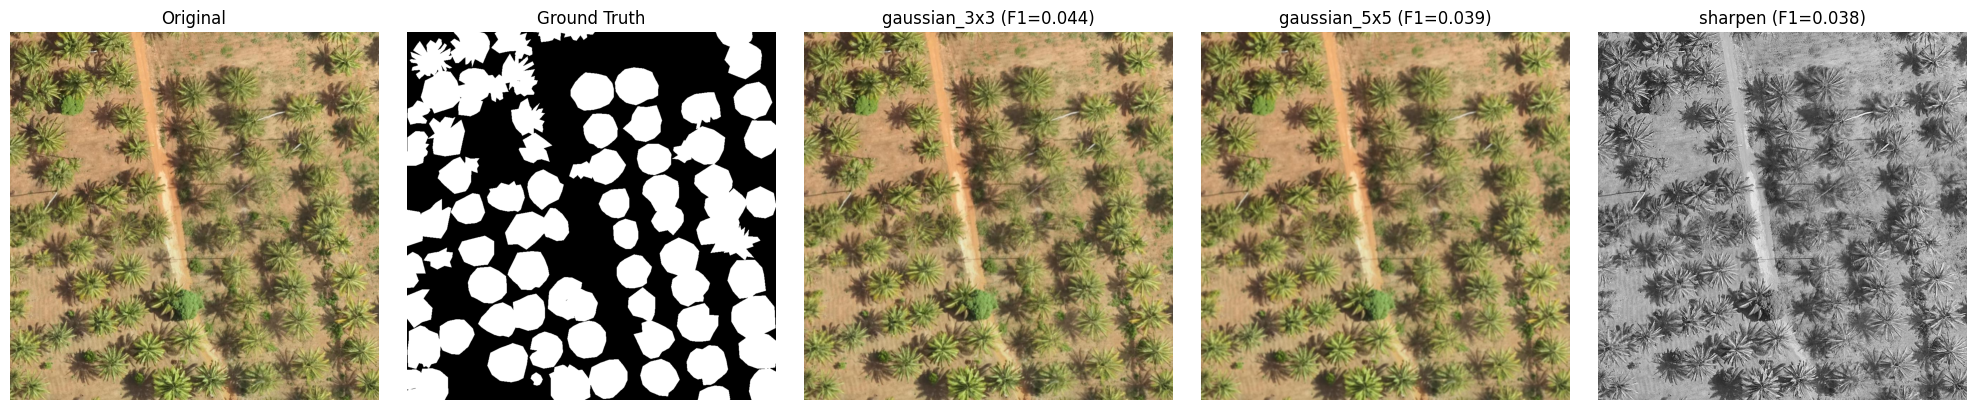

In [5]:
# Visualize top 3 filters on a sample image
sample_entry = sample_entries[0]
img, mask = load_sample_with_mask(sample_entry, train_dir)
filters = apply_all_filters(img)

t(f"Visual comparison: {sample_entry.image_path.name}")

# Show original, mask, and top 3 filters
images_to_show = [img, mask]
titles = ['Original', 'Ground Truth']

for fname in top_3_filters:
    images_to_show.append(filters[fname])
    titles.append(f"{fname} (F1={summary.loc[fname, 'edge_f1_mean']:.3f})")

show_side_by_side(
        *images_to_show,
        titles = tuple(titles),
        cmaps = tuple([None, 'gray'] + ['gray'] * len(top_3_filters))
)


#### Step 6: Combining Multiple Filters Strategy

**Create a 3-channel "enhanced" image using the top 3 filters as RGB channels.**


=== Multi-channel Enhanced Image ===


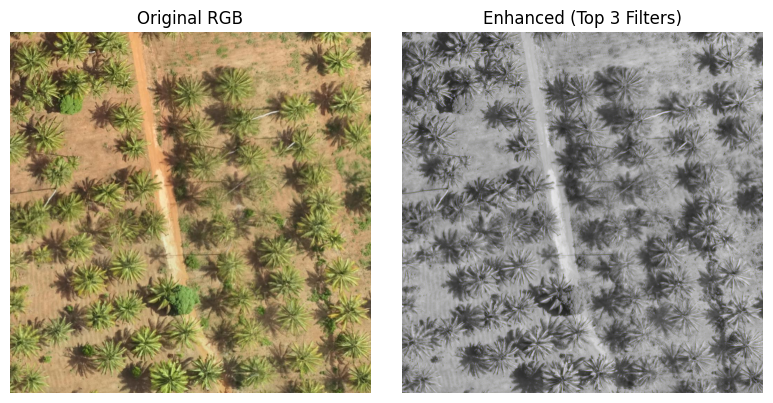

In [6]:



# Test on sample
enhanced_img = create_enhanced_image(img, top_3_filters)

t("Multi-channel Enhanced Image")
show_side_by_side(
        img,
        enhanced_img,
        titles = ("Original RGB", f"Enhanced (Top 3 Filters)")
)


#### Step 7: Export Results


In [9]:
# Save detailed results
output_path = config.paths.models / "filter_analysis.csv"
df.to_csv(output_path, index = False)
p("Saved detailed results", output_path)

# Save summary
summary_path = config.paths.models / "filter_summary.csv"
summary.to_csv(summary_path)
p("Saved summary", summary_path)

# Save top 3 filters to config
p("TOP_3_FILTERS", top_3_filters)


Saved detailed results: C:\github\Tree-Canopy-Detection\checkpoints\filter_analysis.csv
Saved summary: C:\github\Tree-Canopy-Detection\checkpoints\filter_summary.csv
TOP_3_FILTERS: 3 items
  0: gaussian_3x3
  1: gaussian_5x5
  2: sharpen


#### Step 8: Comparison Visualization Grid


=== Comprehensive Filter Comparison ===


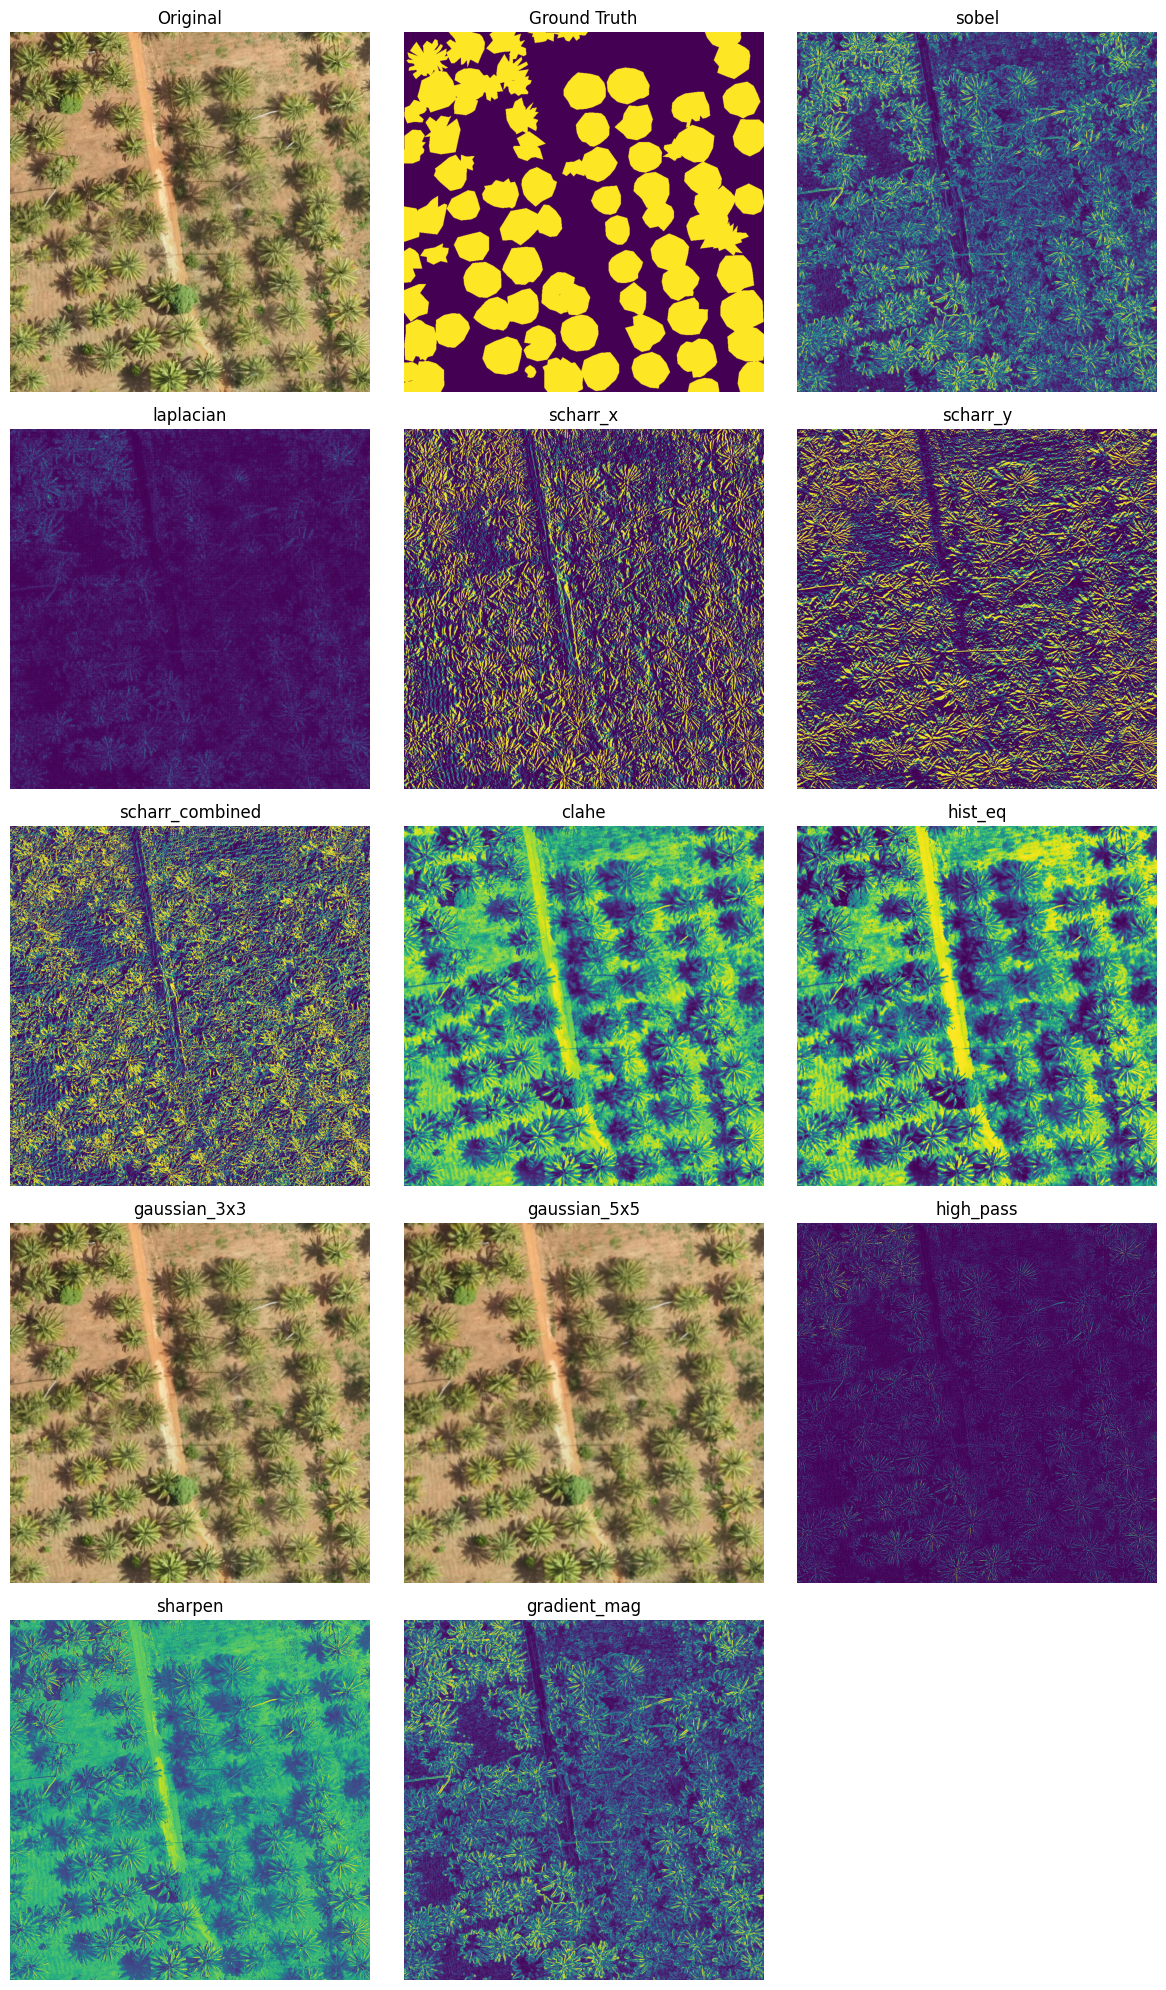

In [8]:
# Create comprehensive comparison for one image
t("Comprehensive Filter Comparison")

sample_entry = sample_entries[0]
img, mask = load_sample_with_mask(sample_entry, train_dir)
filters = apply_all_filters(img)

# Prepare all filters for visualization
all_filters = list(filters.keys())
images = [img, mask] + [filters[f] for f in all_filters]
titles_all = ['Original', 'Ground Truth'] + all_filters

show_side_by_side(
        *images,
        titles = tuple(titles_all),
        maxcolumns = 3
)
